In [50]:
import pandas as pd
import sqlite3

In [51]:
connect = sqlite3.connect('../../data/checking-logs.sqlite')

In [52]:
query = """
SELECT datetime
FROM pageviews
WHERE uid LIKE 'user%
group by date'
"""
result = pd.io.sql.read_sql(query, connect)
result

,datetime


In [53]:
query = """
SELECT 
    DATE(datetime) AS date_only,
    COUNT(*) AS views_per_day
FROM pageviews
WHERE uid LIKE 'user%'
GROUP BY DATE(datetime)
"""
result = pd.io.sql.read_sql(query, connect)
result

,date_only,views_per_day
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


In [54]:
result = pd.read_sql_query(query, connect)
# Преобразуем столбец date_only в тип datetime
result['date_only'] = pd.to_datetime(result['date_only'])

result.set_index('date_only', inplace=True)

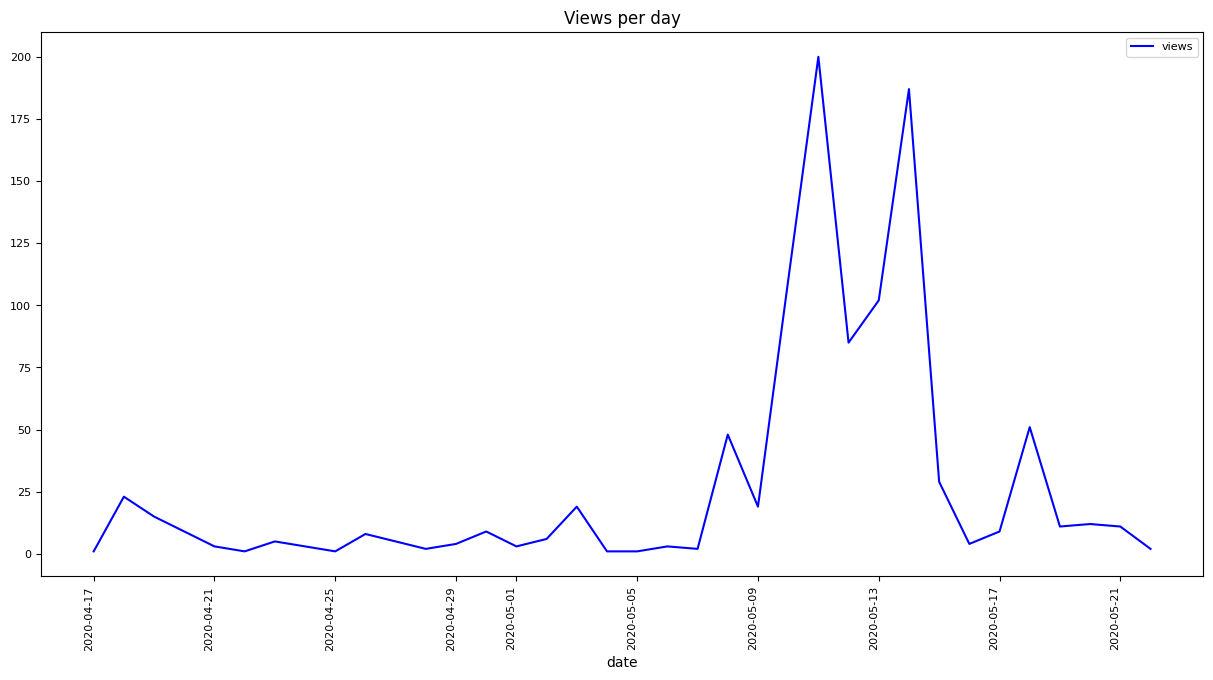

In [57]:


ax = result['views_per_day'].plot(
    figsize=(15, 8),
    title='Views per day',
    xlabel='date',
    color='blue',
    fontsize=8,
    label = 'views',
    rot=90
)
ax.legend(fontsize=8)

In [56]:
connect.close()